In [1]:
from mindquantum.core.gates import *
from mindquantum.core.circuit import *

import numpy as np
from numpy import pi,cos,sin

In [2]:
%run My_plot.py

%run My_QCircuit.py

In [3]:
%run My_QClassification_Algorithm.py

%run My_QNN.py

## 1.Self-defined training function

In [4]:
def cost_func(dist, y_tar, ancella_data = None):
    q_exps = qubit_exps( torch.tensor(dist), qs = ancella_data )
    y_gen = q_exps/2+torch.tensor(0.5)
    
    y_tar = one_hot_encoding(torch.tensor(y_tar), y_gen)
    
    loss = loss_fn(torch.tensor(y_tar), torch.tensor(y_gen), loss_type="l2norm").detach().numpy()
    
    return float(loss)

In [5]:
def traing(qc,
           x_train_data,
           y_train_data,
           Hyper_param ,
           x_test_data = None,
           y_test_data = None,
           loss_type = "l2norm",
           ancella_data = [2, 3],
           random_seed = 1,
           cost_fn = None,
           params_name_dict = None,
           measure_type = "state_vector",
           shots=500,
           print_epoch = 10,
           if_plot = True,
          ):

    # 1. Define metric lists
    Metric_dict = {"train_loss":[],
                   "train_acc":[],
                   "test_loss":[],
                   "test_acc":[],
                   "params":[],
                   "qnn":[],
                  }
    
    # 2.Define the Optimizer
    optimizer=Optimizer(Hyper_param['learning_rate'],
                        beta = Hyper_param['beta_optimizer'],
                        beta_spsa = Hyper_param['beta_spsa'],
                        epsilon = 1e-8, 
                        spsa_params = Hyper_param['spsa_params'],
                        optim = Hyper_param['opt'],
                       )
    
    # 3.Define the QNN
    qnn=QNN(qc,
            params_name_dict,
            measure_type=measure_type,
            optimizer=optimizer,
            shots=shots, # only work when 'measure_type = sampling'
           )
    
    qnn.n_vq = Hyper_param["n_vq"]
    qnn.initialize_parameters(random_seed = random_seed, random_type = "uniform",amp = 1)
    
    n_valid_q = qnn.nq - qnn.n_vq
    
    # 4.Train
    print("Epoch||loss_train||acc_train||loss_test||acc_test")
        
    num_epochs = Hyper_param['num_epochs']
    start=time.time()
    for epoch in range(num_epochs):
        
        # a. Obtain the gradients
        
        grads = qnn.backward(input_data=x_train_data,
                             target_data = y_train_data,
                             cost_fn = cost_func,
                             ancella_data = ancella_data
                            )
        qnn.step(grads)
        
        # b.Obtain the output and loss from the QNN

        # b. Record training results
        # b.1 Training set loss and accuracy
        gen_dist_train = qnn.forward(x_train_data)
        train_loss = cost_fn(gen_dist_train, y_train_data, ancella_data)
        train_acc = Acc(y_train_data, 
                                gen_dist_train,
                                qs=ancella_data, 
                                data_type = "dist" )
        
        Metric_dict["train_loss"].append(float(train_loss))
        Metric_dict["train_acc"].append(float(train_acc))

        
        # c.2 Test set loss and accuracy
        if x_test_data is not None:
            gen_dist_test = qnn.forward(x_test_data)
            test_loss = cost_fn(gen_dist_test, y_test_data, ancella_data)
            test_acc = Acc(y_test_data, 
                                    gen_dist_test,
                                    qs=ancella_data, 
                                    data_type = "dist" )
        else:
            test_loss = 0.0
            test_acc = 0.0

        Metric_dict["test_loss"].append(float(test_loss))
        Metric_dict["test_acc"].append(float(test_acc))
        
        if epoch%print_epoch == 0 or epoch == num_epochs-1:
            print(f'{epoch}||{round(Metric_dict["train_loss"][-1],5)}||{round(Metric_dict["train_acc"][-1],4)}||'
                  +f'{round(Metric_dict["test_loss"][-1],5)}||{round(Metric_dict["test_acc"][-1],4)}')


    print(f"Total time consumed: {round((time.time() - start) / 60, 2)} min")
    
    if if_plot == True:
        plot_training_progress([Metric_dict[key] for key in ["train_loss","train_acc","test_loss","test_acc"]],
                               xlabel="Iteration",ylabel="Loss",title="Loss",
                               label=["train_loss","test_loss","train_acc","test_acc"],
                           color=["C0","C1","C2","C3"],figsize=(6,4),save=False,path=None,show=True)
    
    return copy.deepcopy(Metric_dict)

## 2.Self-defined Circle dataset

In [6]:
# Generate 2D spiral data with two classes and rotational symmetry
def generate_symmetric_spiral(points_per_class=100, radius=1.2, angle=1.5*pi, noise=0.1, shuffle=True, random_state=123):
    
    np.random.seed(random_state)
    
    r = np.linspace(0, radius, points_per_class)  # Radius
    t = np.linspace(0., angle, points_per_class) + np.random.randn(points_per_class) * noise  # Angle
    #t=(t-min(t))

    # Class 1: Original spiral
    X1 = np.c_[r * np.sin(t), r * np.cos(t)]
    X1+=pi/2+0.02
    y1 = np.zeros(points_per_class,dtype=np.int32)

    # Class 2: Rotated by π (180 degrees)
    X2 = np.c_[-r * np.sin(t), -r * np.cos(t)]
    X2+=pi/2-0.02
    y2 = np.ones(points_per_class,dtype=np.int32)

    # Combine the two classes
    x_data = np.vstack([X1, X2])
    y_data = np.hstack([y1, y2])
    
    # Shuffle the dataset
    if shuffle:
        indices = np.arange(x_data.shape[0])
        np.random.shuffle(indices)
        x_data = x_data[indices]
        y_data = y_data[indices]
    return x_data, y_data


def Nonlinear_data_generator(num_samples=1000, random_state=123):

    num_spiral = num_samples//2
        
    x_data, y_data = generate_symmetric_spiral(points_per_class=num_spiral, 
                                               radius=1.3, 
                                               angle=1.6*pi, 
                                               noise=0.15, 
                                               shuffle=True,
                                               random_state=random_state)
    x_data, y_data = list(x_data), list(y_data)
        
    x_data=np.array(x_data)
    y_data=np.array(y_data)
    
    return x_data,y_data

def data_repeat(x_data, num_repeats=2):
    x_repeat = x_data
    for k in range(num_repeats-1):
        x_repeat=np.append(x_repeat,x_data,axis=1)
    return x_repeat

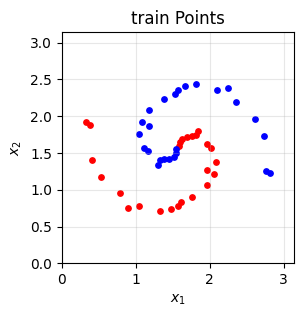

train_data(% of y>0.5): 0.5
x_train_data.shape: (50, 8)


In [7]:
num_train=50
num_repeats=4

x_train_data, y_train_data = Nonlinear_data_generator(num_train,random_state=125)
x_train_data=data_repeat(x_train_data, num_repeats)

plot_classified_points([[x_train_data[:,0:2], y_train_data]],
                       colors=[["red","blue"]], 
                       xlim=[0,pi],ylim=[0,pi],
                       title='train Points', 
                       figsize=(3,3),
                      ponts_sizes=[15,15]
                      )

# Ensure data balance; otherwise, the model may easily fall into a local minimum
print("train_data(% of y>0.5):",sum(y_train_data)/num_train)

print("x_train_data.shape:",x_train_data.shape)

## 3.Construct the parameterised quantum circuit

In [8]:
def qc_ADE_QNN():
    """
    Function:
        - Define the circuit of ADE-QNN
    """
    
    qc = Circuit()
    
    prg_enc = PRGenerator("a")
    prg = PRGenerator("x")
    
    
    # 1. Add input layer
    for q in range(4):
        qc += RY(prg_enc.new()).on(q)
    qc += BarrierGate()
        
    
    # 2. Add hidden layer 1
    qc += qc_Hidden_Layer1(prg)
    
    # 3. Add re-uploading layer
    prg_enc.reset()
    for q in range(4):
        qc += RZ(prg_enc.new()).on(q)
    qc += BarrierGate()
        
    # 4. Add hidden layer 2
    qc += qc_Hidden_Layer2(prg, MCRY=True)
    
    # 5. Generate the parameter_name_dict
    params_enc=["a"+str(k) for k in range(prg_enc.size())]
    params_train=["x"+str(k) for k in range(prg.size())]
    params_name_dict={"encode_params_name": params_enc,
                  "weight_params_name": params_train,
                  "params_name": list(set(params_enc+params_train))
                 }
    
    return qc,params_name_dict

In [9]:
def qc_Standard_QNN():
    """
    Function:
        - Define the circuit of ADE-QNN
    """
    
    qc = Circuit()
    
    prg_enc = PRGenerator("a")
    prg = PRGenerator("x")
    
    
    # 1. Add input layer
    for q in [0,2]:
        qc += RY(prg_enc.new()).on(q)
    qc += BarrierGate()
    
    # 2. Add hidden layer 1
    qc += qc_Hidden_Layer1(prg)
        
    # 3. Add hidden layer 2
    qc += qc_Hidden_Layer2(prg, MCRY=False)
    
    # 4. Generate the parameter_name_dict
    params_enc=["a"+str(k) for k in range(prg_enc.size())]
    params_train=["x"+str(k) for k in range(prg.size())]
    params_name_dict={"encode_params_name": params_enc,
                  "weight_params_name": params_train,
                  "params_name": list(set(params_enc+params_train))
                 }
    
    return qc,params_name_dict

ADE-QNN:


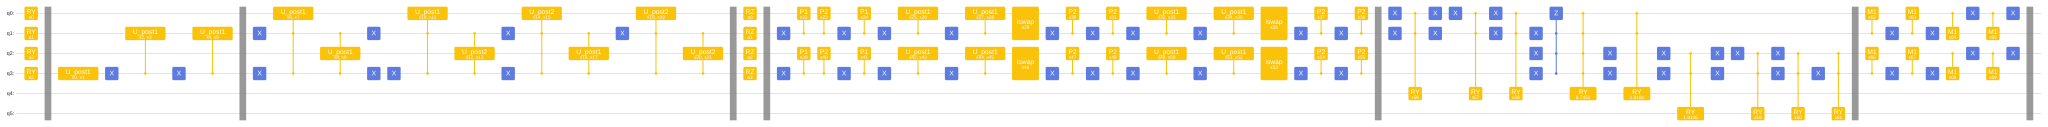

Standard-QNN:


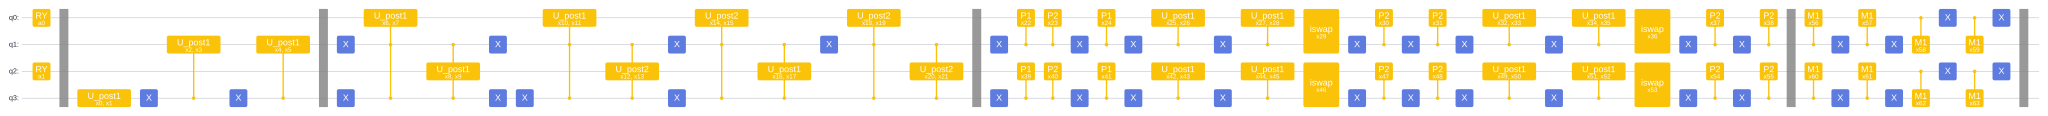

In [10]:
# Show the quantum circuit of ADE-QNN
qc_ADE,params_name_dict_ADE = qc_ADE_QNN()
print("ADE-QNN:")
display(qc_ADE.svg())

# Show the quantum circuit of Standard QNN
qc_Standard,params_name_dict_Standard = qc_Standard_QNN()
print("Standard-QNN:")
display(qc_Standard.svg())

## 3.Train

In [11]:
def calc_mean_std(runs):
    """
    Compute the mean and standard deviation of multiple training curves.
    :param runs: lists/arrays, where each element is one training curve.
    :return: mean (NumPy array), std (NumPy array)
    """
    arr = np.array(runs)  # shape: (num_runs, num_iterations)
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    return mean, std

### 3.1 Training of ADE-QNN

In [12]:
Metric_dict_all = {
        "train_loss":[],
        "train_acc":[],
        "test_loss":[],
        "test_acc":[]
    }

hyper_parameters = {
    "num_epochs": 200,
    "learning_rate": 0.05,
    "spsa_params": {"c":0.1, "min_ck": 0.05, "A":30, "n_spsa_sample":2},
    "beta_spsa":(0,0.15),
    "beta_optimizer":(0.9,0.99),
    "opt": "SPSA-AMSGrad",
    "n_vq": 2
                   }

num_repeats = 10
for r in range(num_repeats):
    print("\nRepeat:"+str(r+1),"\n")
    data_dict = traing(qc_ADE,
                       x_train_data,
                       y_train_data,
                       Hyper_param = hyper_parameters,
                       x_test_data = None,
                       y_test_data = None,
                       loss_type = "l2norm",
                       ancella_data = [2, 3],
                       random_seed = r,
                       cost_fn = cost_func,
                       params_name_dict = params_name_dict_ADE,
                       measure_type = "state_vector",
                       shots=500,
                       print_epoch = 20,
                       if_plot = False,
                      )
    for key in Metric_dict_all.keys():
        Metric_dict_all[key].append(data_dict[key])


Repeat:1 

Epoch||loss_train||acc_train||loss_test||acc_test
0||0.49657||0.56||0.0||0.0


C:\Users\29022\AppData\Local\Temp\ipykernel_21336\619917004.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_fn(torch.tensor(y_tar), torch.tensor(y_gen), loss_type="l2norm").detach().numpy()


20||0.39517||0.7||0.0||0.0
40||0.33032||0.78||0.0||0.0
60||0.29855||0.8||0.0||0.0
80||0.28632||0.78||0.0||0.0
100||0.27491||0.78||0.0||0.0
120||0.26155||0.78||0.0||0.0
140||0.25637||0.78||0.0||0.0
160||0.244||0.82||0.0||0.0
180||0.23385||0.82||0.0||0.0
199||0.24639||0.82||0.0||0.0
Total time consumed: 1.04 min

Repeat:2 

Epoch||loss_train||acc_train||loss_test||acc_test
0||0.44487||0.74||0.0||0.0
20||0.38071||0.68||0.0||0.0
40||0.33393||0.68||0.0||0.0
60||0.30848||0.78||0.0||0.0
80||0.25816||0.86||0.0||0.0
100||0.24272||0.8||0.0||0.0
120||0.21751||0.94||0.0||0.0
140||0.17982||0.9||0.0||0.0
160||0.19335||0.9||0.0||0.0
180||0.21833||0.88||0.0||0.0
199||0.21865||0.94||0.0||0.0
Total time consumed: 1.09 min

Repeat:3 

Epoch||loss_train||acc_train||loss_test||acc_test
0||0.49541||0.72||0.0||0.0
20||0.37015||0.64||0.0||0.0
40||0.3188||0.68||0.0||0.0
60||0.29518||0.74||0.0||0.0
80||0.27888||0.8||0.0||0.0
100||0.28145||0.78||0.0||0.0
120||0.30138||0.8||0.0||0.0
140||0.2435||0.82||0.0||0.0
16

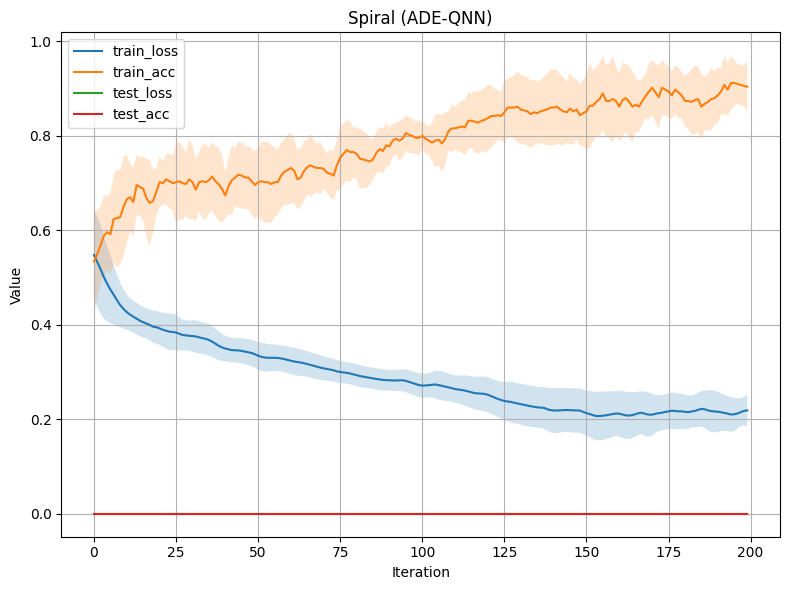

In [13]:
# Save the data
mean, std = calc_mean_std(Metric_dict_all["train_acc"])
data_ADE = np.array([mean, std])
np.save("data/Spiral_Train_Acc_ADE.npy", data_ADE)

# Plot the mean results
plot_mean_std(Metric_dict_all,title = "Spiral (ADE-QNN)")

### 3.2 Training of Standard QNN 

In [14]:
Metric_dict_all = {
        "train_loss":[],
        "train_acc":[],
        "test_loss":[],
        "test_acc":[]
    }

hyper_parameters = {
    "num_epochs": 200,
    "learning_rate": 0.05,
    "spsa_params": {"c":0.1, "min_ck": 0.05, "A":30, "n_spsa_sample":2},
    "beta_spsa":(0.,0.15),
    "beta_optimizer":(0.9,0.99),
    "opt": "SPSA-AMSGrad",
    "n_vq": 0
                   }

num_repeats = 10
for r in range(num_repeats):
    print("\nRepeat:"+str(r+1),"\n")
    data_dict = traing(qc_Standard,
                       x_train_data,
                       y_train_data,
                       Hyper_param = hyper_parameters,
                       x_test_data = None,
                       y_test_data = None,
                       loss_type = "l2norm",
                       ancella_data = [2, 3],
                       random_seed = r,
                       cost_fn = cost_func,
                       params_name_dict = params_name_dict_Standard,
                       measure_type = "state_vector",
                       shots=500,
                       print_epoch = 20,
                       if_plot = False,
                      )
    for key in Metric_dict_all.keys():
        Metric_dict_all[key].append(data_dict[key])


Repeat:1 

Epoch||loss_train||acc_train||loss_test||acc_test


C:\Users\29022\AppData\Local\Temp\ipykernel_21336\619917004.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_fn(torch.tensor(y_tar), torch.tensor(y_gen), loss_type="l2norm").detach().numpy()


0||0.56987||0.5||0.0||0.0
20||0.45151||0.66||0.0||0.0
40||0.39434||0.64||0.0||0.0
60||0.37693||0.56||0.0||0.0
80||0.37812||0.6||0.0||0.0
100||0.37499||0.6||0.0||0.0
120||0.37463||0.66||0.0||0.0
140||0.37157||0.62||0.0||0.0
160||0.36884||0.6||0.0||0.0
180||0.36869||0.56||0.0||0.0
199||0.36794||0.58||0.0||0.0
Total time consumed: 0.89 min

Repeat:2 

Epoch||loss_train||acc_train||loss_test||acc_test
0||0.58051||0.48||0.0||0.0
20||0.42482||0.58||0.0||0.0
40||0.37928||0.62||0.0||0.0
60||0.36878||0.58||0.0||0.0
80||0.36804||0.58||0.0||0.0
100||0.36755||0.58||0.0||0.0
120||0.36727||0.56||0.0||0.0
140||0.3671||0.58||0.0||0.0
160||0.36692||0.58||0.0||0.0
180||0.36682||0.56||0.0||0.0
199||0.36678||0.58||0.0||0.0
Total time consumed: 0.88 min

Repeat:3 

Epoch||loss_train||acc_train||loss_test||acc_test
0||0.45275||0.7||0.0||0.0
20||0.38069||0.64||0.0||0.0
40||0.38045||0.66||0.0||0.0
60||0.37262||0.6||0.0||0.0
80||0.36871||0.62||0.0||0.0
100||0.37096||0.62||0.0||0.0
120||0.36853||0.6||0.0||0.0
1

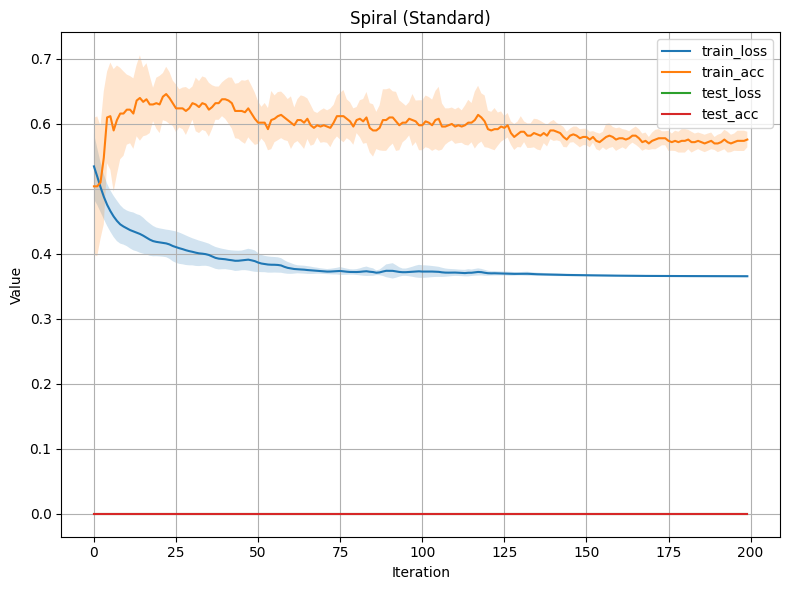

In [15]:
# Save the data
mean, std = calc_mean_std(Metric_dict_all["train_acc"])
data_Standard = np.array([mean, std])
np.save("data/Spiral_Train_Acc_Standard.npy", data_Standard)

# Plot the mean results
plot_mean_std(Metric_dict_all,title = "Spiral (Standard)")

## 4.Performance Comparison

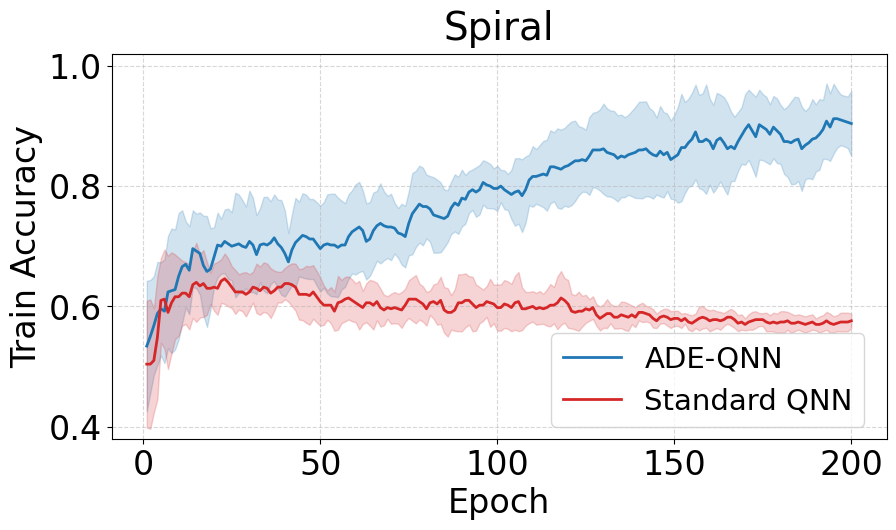

In [16]:
font_labels={"family":"DejaVu Sans","size":24}
font_ticks={"family":"DejaVu Sans","size":24}
font_titles={"family":"DejaVu Sans","size":28}
font_legend={"family":"DejaVu Sans","size":21}

data_ADE = np.load("data/Spiral_Train_Acc_ADE.npy")
data_Standard = np.load("data/Spiral_Train_Acc_Standard.npy")


x = range(1,len(data_ADE[0])+1)

c1 = "C0"
c2 = "C3"

"""1.Plot the results of ADE-QNN"""
fig,ax1=plt.subplots(figsize=(10,5))

ax1.plot(x, data_ADE[0],
         linestyle='-',      # Line style: '--' dashed, '-' solid, ':' dotted, '-.' dash-dot
         linewidth=2,         # Line width
         color=c1,        # Line color
         marker=None,          # Marker shape: 'o' circle, 's' square, '^' triangle
         markersize=6,        # Marker size
         markeredgewidth = 2,
         markerfacecolor='white',  # Marker fill color
         markeredgecolor=c1, # Marker edge color
         label = "ADE-QNN"
         )
ax1.fill_between(x, 
                np.array(data_ADE[0]) - np.array(data_ADE[1]), 
                np.array(data_ADE[0]) + np.array(data_ADE[1]),
                alpha=0.2, color=c1, label=None)

"""2.Plot the results of Standard QNN"""

ax1.plot(x, data_Standard[0],
         linestyle='-',      # Line style: '--' dashed, '-' solid, ':' dotted, '-.' dash-dot
         linewidth=2,         # Line width
         color=c2,        # Line color
         marker=None,          # Marker shape: 'o' circle, 's' square, '^' triangle
         markersize=6,        # Marker size
         markeredgewidth = 2,
         markerfacecolor='white',  # Marker fill color
         markeredgecolor=c2, # Marker edge color
         label = "Standard QNN"
         )
ax1.fill_between(x, 
                np.array(data_Standard[0]) - np.array(data_Standard[1]), 
                np.array(data_Standard[0]) + np.array(data_Standard[1]),
                alpha=0.2, color=c2, label=None)

"""3.Set axes labels"""

ax1.set_title("Spiral",fontdict=font_titles,pad = 10)
ax1.set_xlabel("Epoch",fontdict=font_labels)
ax1.set_ylabel("Train Accuracy",fontdict=font_labels)

ax1.set_ylim(0.38,1.02)

ax1.tick_params(labelsize=font_ticks["size"])
labels=ax1.get_xticklabels()+ax1.get_yticklabels()
[label.set_fontname(font_ticks["family"]) for label in labels]

fig.legend(loc='upper left', bbox_to_anchor=(0.55, 0.35),prop=font_legend)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()